<a href="https://colab.research.google.com/github/juliamota1/CN-unifesp/blob/main/atividade5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lista de Exercícios — Sistemas Lineares e Implementação Numérica

**Disciplina:** Cálculo Numérico  
**Nome:** Julia dos Santos Mota

---



## Resoluções manuais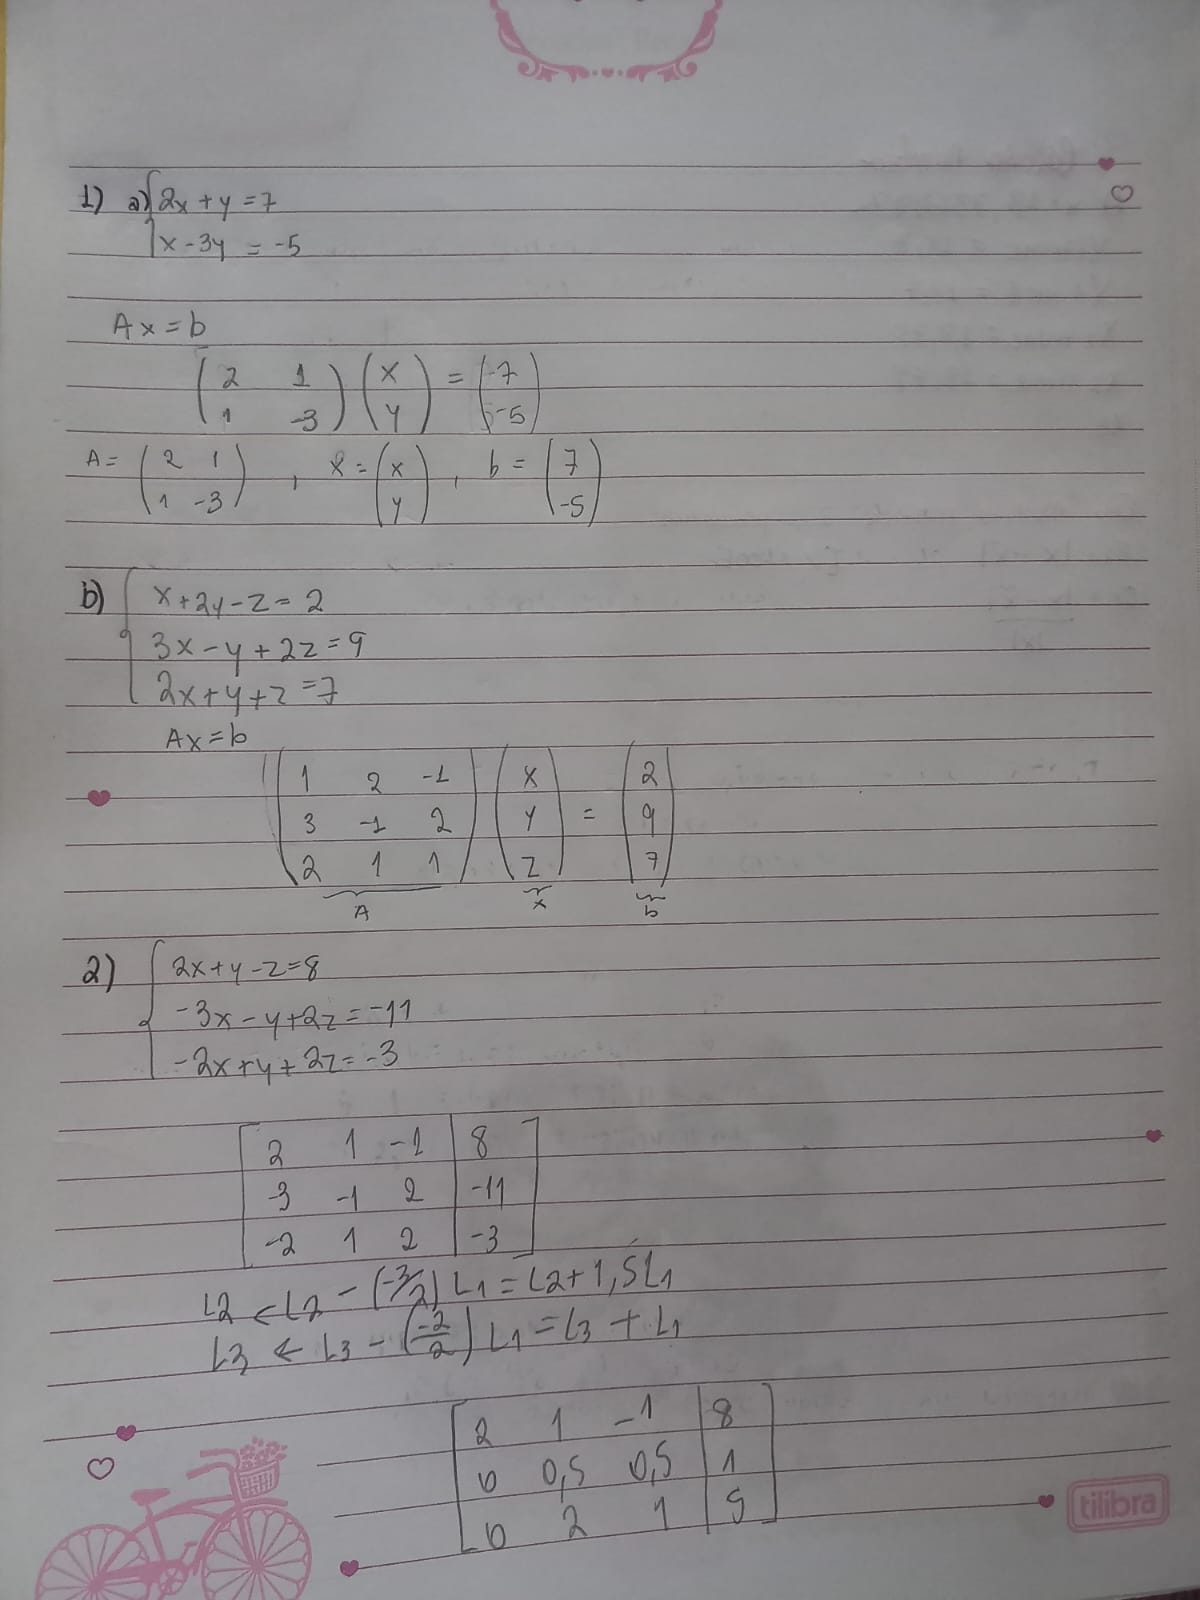

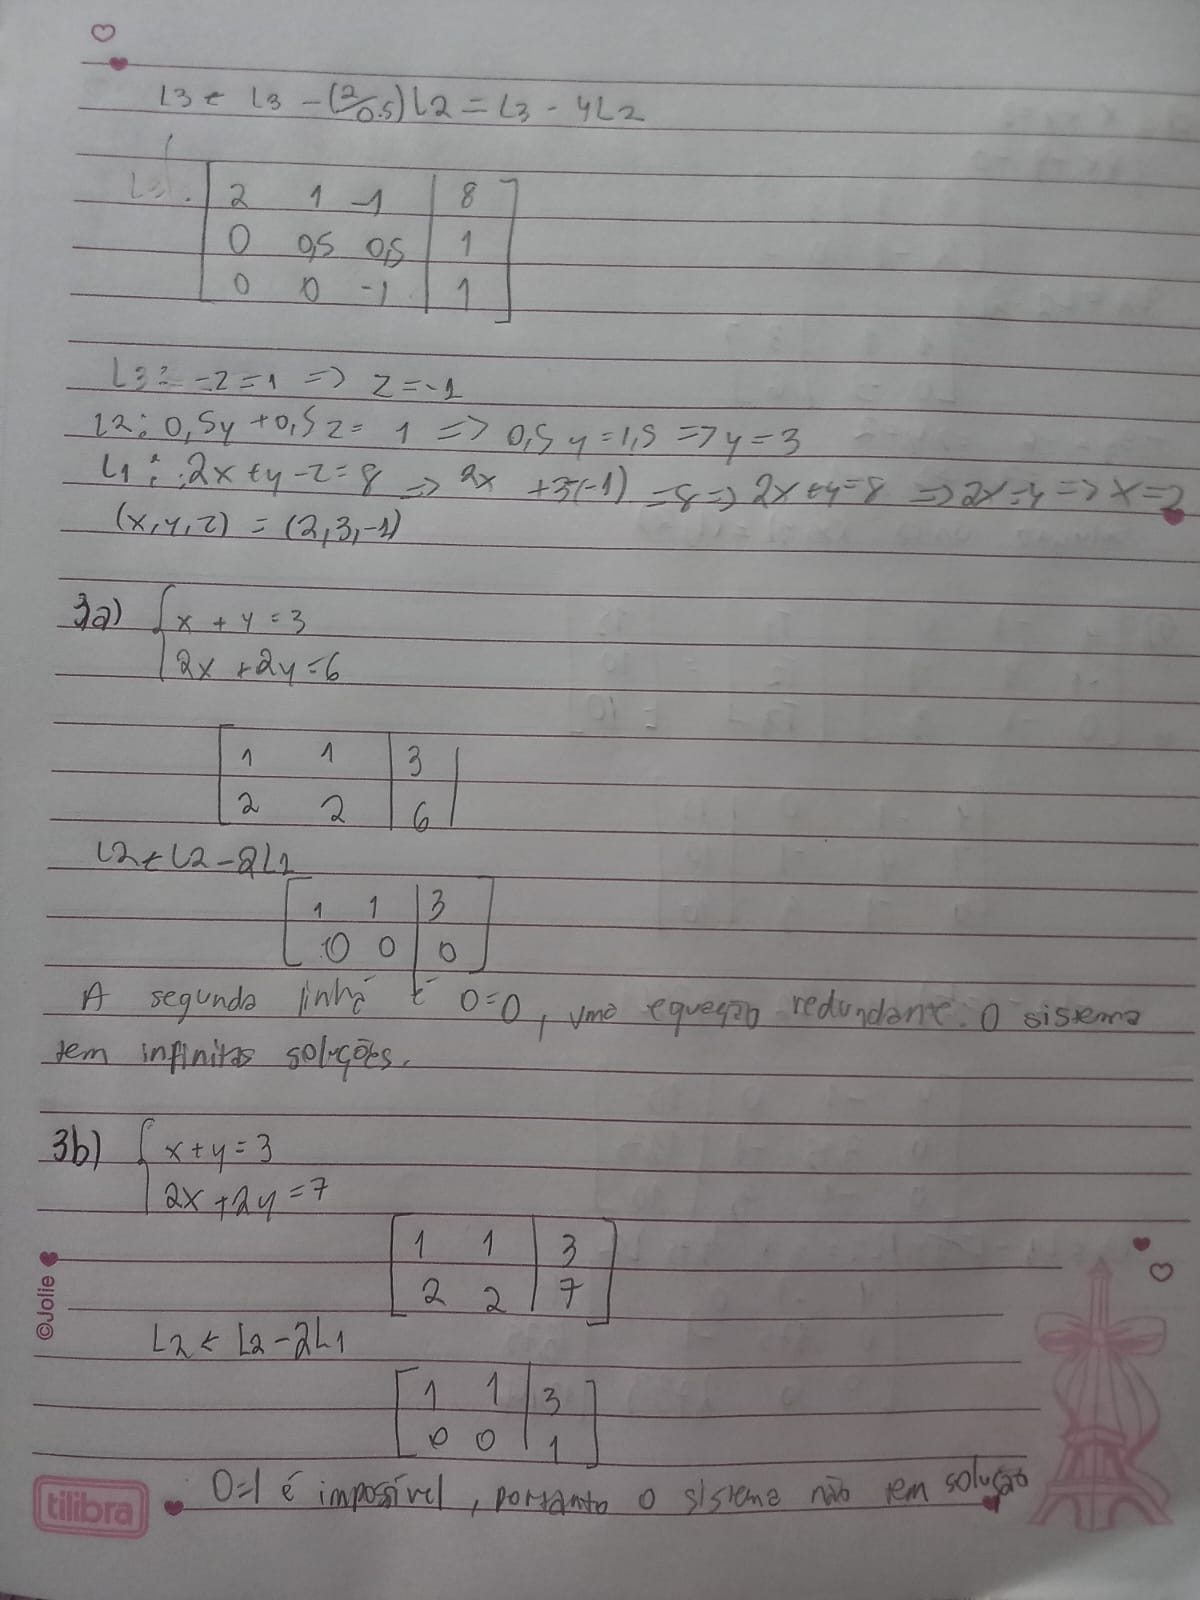

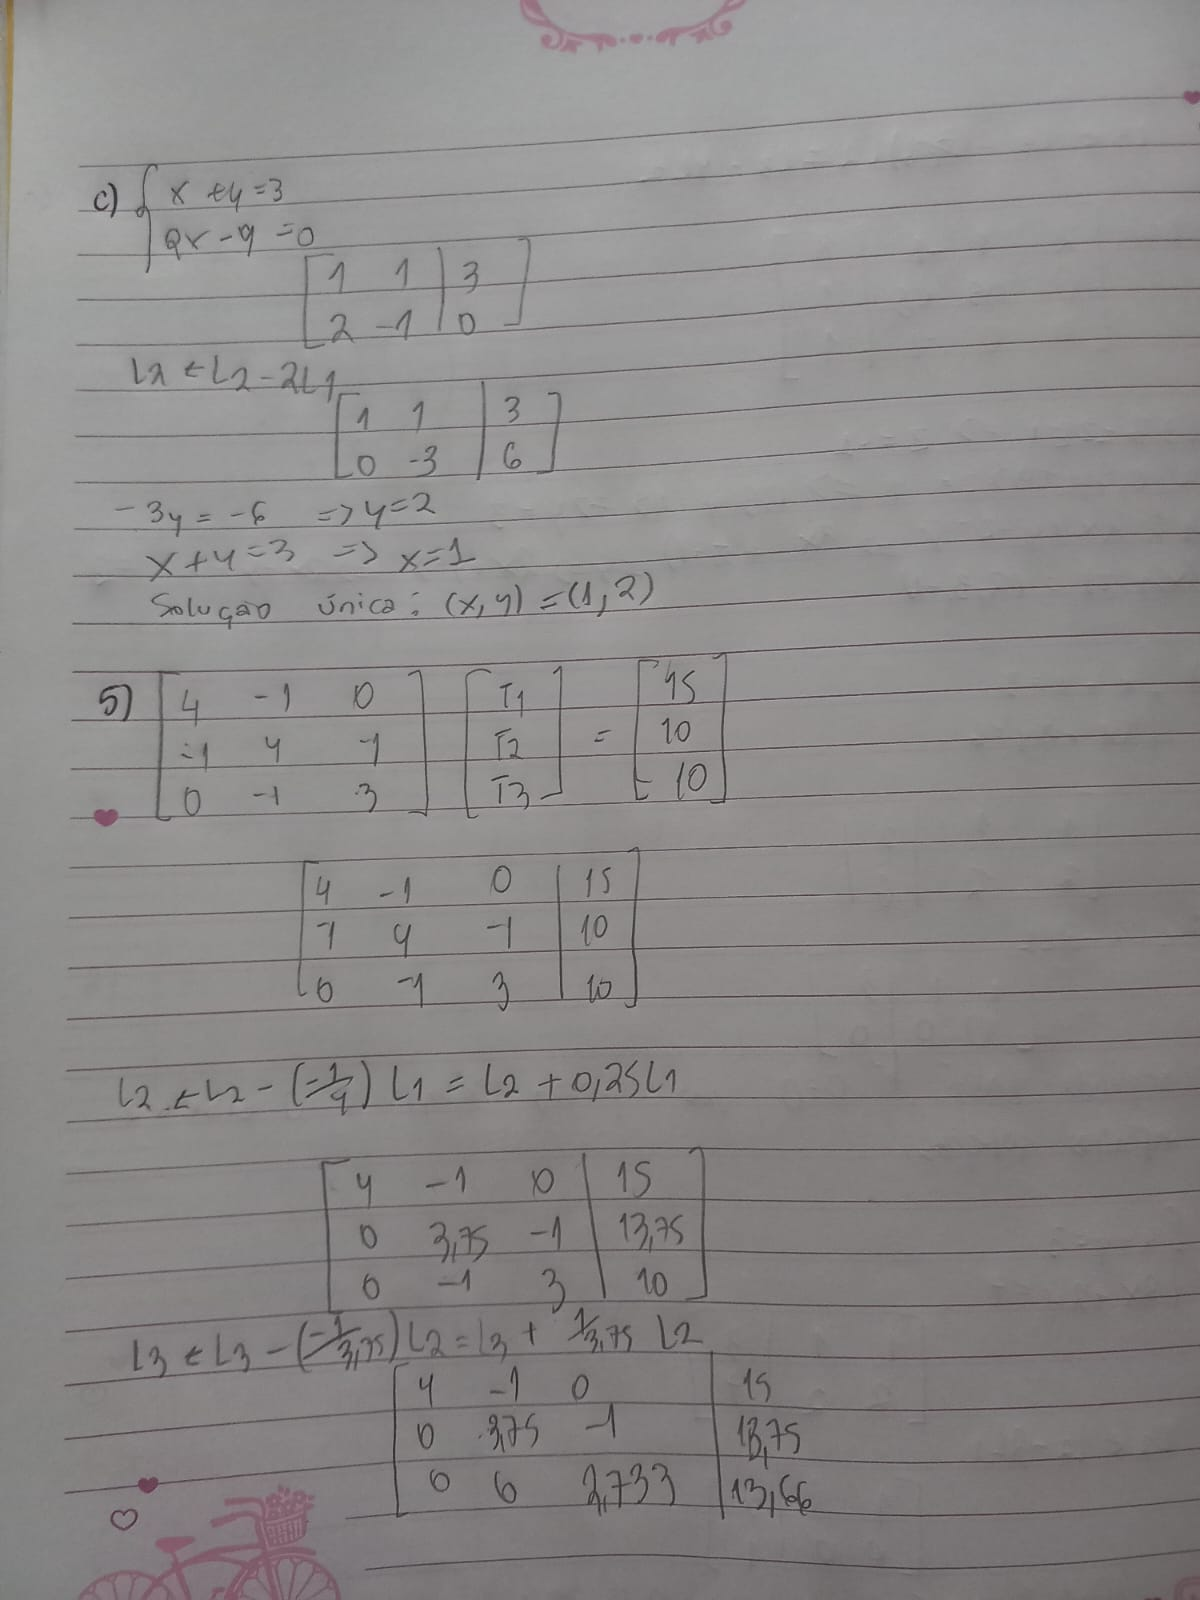

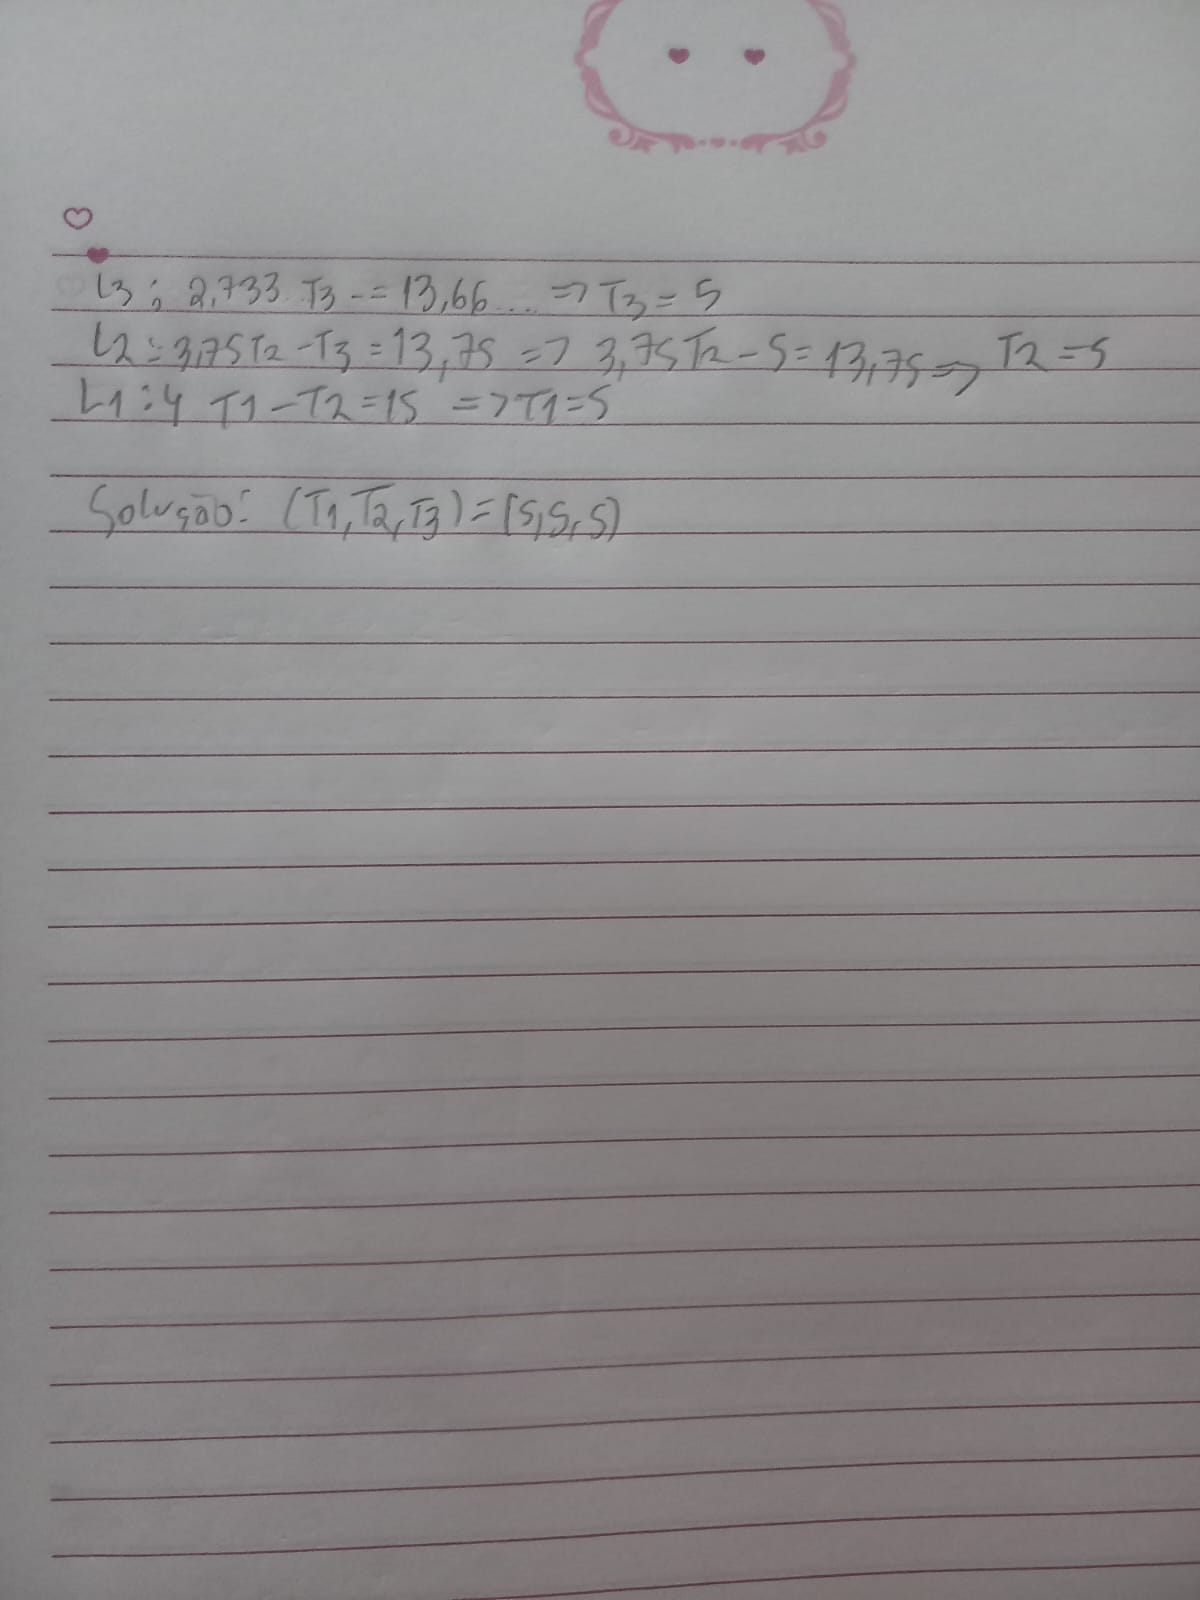

In [ ]:
import numpy as np

def gauss_sem_pivot(A, b):
    """
    Resolve Ax = b via eliminação de Gauss sem pivotamento.

    Parâmetros:
        A : np.ndarray (n x n) — matriz dos coeficientes
        b : np.ndarray (n,)   — vetor independente

    Retorna:
        x : np.ndarray (n,)   — vetor solução
    """
    A = A.astype(float).copy()
    b = b.astype(float).copy()
    n = len(b)

    # Matriz aumentada [A | b]
    Ab = np.hstack([A, b.reshape(-1, 1)])

    # Eliminação progressiva
    for k in range(n - 1):
        for i in range(k + 1, n):
            fator = Ab[i, k] / Ab[k, k]
            Ab[i, k:] -= fator * Ab[k, k:]

    # Substituição regressiva
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (Ab[i, -1] - np.dot(Ab[i, i+1:n], x[i+1:n])) / Ab[i, i]

    return x

In [ ]:
# Sistema do Exercício 2
A = np.array([[2, 1, -1],
              [-3, -1, 2],
              [-2, 1, 2]], dtype=float)
b = np.array([8, -11, -3], dtype=float)

# Resolução via Gauss sem pivotamento
x_gauss = gauss_sem_pivot(A, b)

# Resolução via numpy (referência)
x_numpy = np.linalg.solve(A, b)

print("Solução via Gauss sem pivotamento:", x_gauss)
print("Solução via numpy.linalg.solve:  ", x_numpy)
print("Diferença (Gauss - numpy):       ", x_gauss - x_numpy)

Solução via Gauss sem pivotamento: [ 2.  3. -1.]
Solução via numpy.linalg.solve:   [ 2.  3. -1.]
Diferença (Gauss - numpy):        [-4.44089210e-16  4.44089210e-16 -5.55111512e-16]


### Interpretação

O método implementado reproduz exatamente a solução obtida manualmente no Exercício 2, \((x, y, z) = (2, 3, -1)\), e coincide com a função `numpy.linalg.solve`. A diferença é nula (ou da ordem do erro de ponto flutuante), confirmando a corretude do algoritmo.

Observação: a eliminação sem pivotamento funciona bem quando os pivôs são não nulos e o sistema é bem condicionado. Em casos com pivôs nulos ou muito próximos de zero, recomenda-se o **pivotamento parcial** para garantir estabilidade numérica.

## Códigos

In [ ]:
# Matriz A e vetor b do modelo térmico
A_termico = np.array([[4, -1, 0],
                      [-1, 4, -1],
                      [0, -1, 3]], dtype=float)
b_termico = np.array([15, 10, 10], dtype=float)

# Resolução via função gauss_sem_pivot definida no Exercício 4
T = gauss_sem_pivot(A_termico, b_termico)

# Verificação com numpy
T_numpy = np.linalg.solve(A_termico, b_termico)

print("Temperaturas via Gauss:")
print(f"  T1 = {T[0]:.4f}")
print(f"  T2 = {T[1]:.4f}")
print(f"  T3 = {T[2]:.4f}")
print()
print("Temperaturas via numpy.linalg.solve:")
print(f"  T1 = {T_numpy[0]:.4f}")
print(f"  T2 = {T_numpy[1]:.4f}")
print(f"  T3 = {T_numpy[2]:.4f}")

Temperaturas via Gauss:
  T1 = 5.0000
  T2 = 5.0000
  T3 = 5.0000

Temperaturas via numpy.linalg.solve:
  T1 = 5.0000
  T2 = 5.0000
  T3 = 5.0000


### Interpretação

As três temperaturas da rede térmica são iguais a \(5\) (na unidade adotada). Isso indica que o sistema está em **equilíbrio térmico uniforme**: não há gradiente de temperatura entre os nós, o que é coerente com a simetria do problema e com os valores do vetor independente.

## Conclusão

A **eliminação de Gauss** é um método direto e eficiente para resolver sistemas lineares de pequeno e médio porte. A implementação sem pivotamento funciona bem quando os pivôs são não nulos e o sistema é bem condicionado, como nos casos estudados.

Em situações com **pivôs nulos ou muito próximos de zero**, recomenda-se o **pivotamento parcial** para garantir estabilidade numérica e evitar divisões por valores muito pequenos, que amplificam erros de arredondamento.

A aplicação ao modelo de balanço térmico mostrou que, para os dados fornecidos, o sistema atinge equilíbrio uniforme em \(T_1 = T_2 = T_3 = 5\), resultado confirmado tanto pela resolução manual quanto pela implementação computacional.